# 序列重复性和正交性分析

本notebook用于检查black_cat.xlsx中序列的第21-30位的重复性和正交性

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def read_library(file_path):
    """读取Excel文件中的序列数据"""
    df = pd.read_excel(file_path, header=None)
    index_list = df.iloc[:, 0]
    library = df.iloc[:, 1]
    return index_list, library

In [3]:
# 读取数据
file_path = '/home/liuycomputing/lby_FASTQ_data_202408/refLib-SEQ2210.xlsx'
index_list, library = read_library(file_path)

print(f"总序列数量: {len(library)}")
print(f"\n前5个序列:")
for i in range(min(5, len(library))):
    seq = str(library.iloc[i])
    print(f"{index_list.iloc[i]}: {seq[:50]}... (长度: {len(seq)})")

总序列数量: 10801

前5个序列:
nan: 0... (长度: 1)
s1: ACACGACGCTCTTCCGATCTCTTACGCTCATAGTGTAAGAAGGGTCTGGT... (长度: 141)
s2: ACACGACGCTCTTCCGATCTCTTGTTCGATACATGGTAGTGTTTCCTGCA... (长度: 141)
s3: ACACGACGCTCTTCCGATCTCAAGTTCGAGTCACGGAAGACAGGTCATGC... (长度: 141)
s4: ACACGACGCTCTTCCGATCTCAAATTAGTAGCGTGTAAGCACTTGCATTG... (长度: 141)


In [4]:
# 提取第21-30位（索引20-29）的子序列
def extract_subsequence(sequence, start=20, end=30):
    """提取序列中指定位置的子序列"""
    seq_str = str(sequence)
    if len(seq_str) >= end:
        return seq_str[start:end]
    else:
        return seq_str[start:] if len(seq_str) > start else ""

# 提取所有序列的21-30位
subsequences = []
for idx, seq in library.items():
    subseq = extract_subsequence(seq)
    subsequences.append(subseq)

print(f"提取的子序列数量: {len(subsequences)}")
print(f"\n前10个子序列:")
for i in range(min(10, len(subsequences))):
    print(f"{i}: {subsequences[i]}")

提取的子序列数量: 10801

前10个子序列:
0: 
1: CTTACGCTCA
2: CTTGTTCGAT
3: CAAGTTCGAG
4: CAAATTAGTA
5: CAAGCTCATA
6: CAAGTTCGCA
7: CAACTTAGAG
8: CACATTCGAG
9: CACGCTCAAG


## 1. 重复序列分析

In [5]:
# 统计子序列的重复情况
subseq_counts = Counter(subsequences)

# 找出重复的子序列
duplicates = {seq: count for seq, count in subseq_counts.items() if count > 1}

print(f"总子序列数量: {len(subsequences)}")
print(f"唯一子序列数量: {len(subseq_counts)}")
print(f"重复子序列种类数: {len(duplicates)}")
print(f"重复子序列总出现次数: {sum(duplicates.values())}")

if duplicates:
    print(f"\n重复率: {sum(duplicates.values()) / len(subsequences) * 100:.2f}%")
    print(f"\n出现频率最高的重复子序列 (Top 20):")
    sorted_duplicates = sorted(duplicates.items(), key=lambda x: x[1], reverse=True)
    for i, (seq, count) in enumerate(sorted_duplicates[:20], 1):
        print(f"{i}. {seq}: 出现 {count} 次")

总子序列数量: 10801
唯一子序列数量: 8307
重复子序列种类数: 1549
重复子序列总出现次数: 4043

重复率: 37.43%

出现频率最高的重复子序列 (Top 20):
1. ACGGCAGCCT: 出现 15 次
2. ACGGCAGGGC: 出现 14 次
3. ATGGCGTGTA: 出现 10 次
4. CAGGAACTTC: 出现 9 次
5. ATAACCTAAG: 出现 9 次
6. ACTCTAGCCT: 出现 9 次
7. ACGACAGGGC: 出现 9 次
8. ACTCTAGAAC: 出现 9 次
9. CGCCTCACCA: 出现 9 次
10. CATCAAGAAT: 出现 8 次
11. CAGTAACGTC: 出现 8 次
12. ACGATACTCT: 出现 8 次
13. ACGACAGAAC: 出现 8 次
14. ACGGCAGAAC: 出现 8 次
15. CAGCAACTAT: 出现 7 次
16. ATTACCTAGC: 出现 7 次
17. AGGGCCGCCT: 出现 7 次
18. CGGGCGTAAG: 出现 7 次
19. CAGCGACCGT: 出现 7 次
20. ATACTCTAGC: 出现 7 次


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS, SimHei
findfont

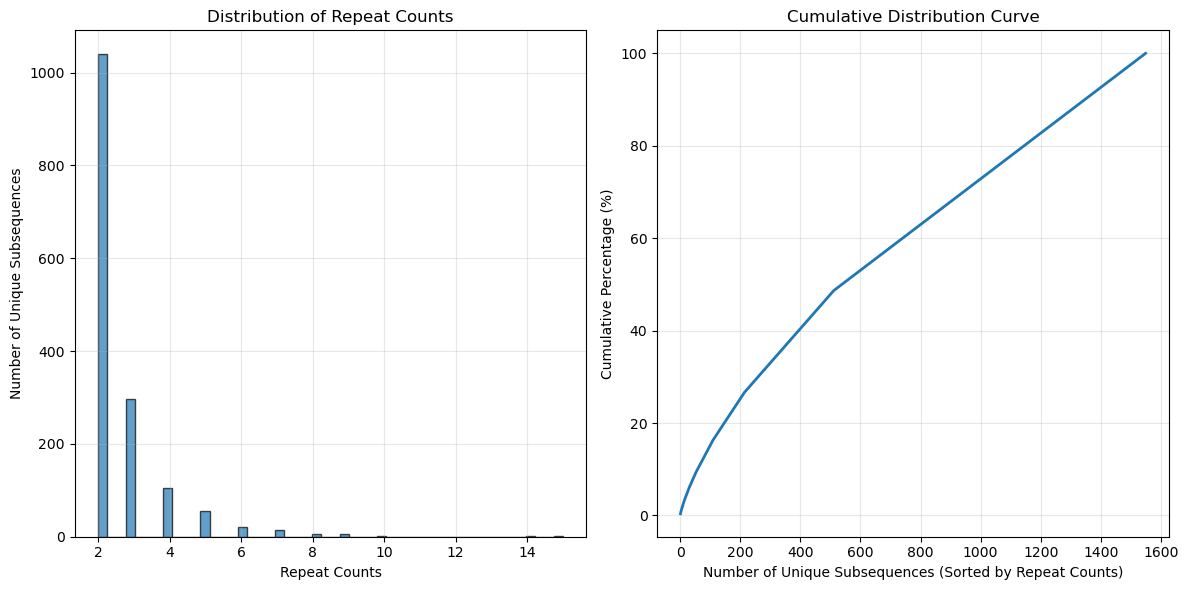

In [7]:
# 可视化重复分布
if duplicates:
    plt.figure(figsize=(12, 6))
    
    # Subplot 1: Distribution of Repeat Counts
    plt.subplot(1, 2, 1)
    repeat_counts = list(duplicates.values())
    plt.hist(repeat_counts, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Repeat Counts')
    plt.ylabel('Number of Unique Subsequences')
    plt.title('Distribution of Repeat Counts')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Cumulative Distribution
    plt.subplot(1, 2, 2)
    sorted_counts = sorted(repeat_counts, reverse=True)
    cumulative = np.cumsum(sorted_counts) / sum(sorted_counts) * 100
    plt.plot(range(1, len(cumulative)+1), cumulative, linewidth=2)
    plt.xlabel('Number of Unique Subsequences (Sorted by Repeat Counts)')
    plt.ylabel('Cumulative Percentage (%)')
    plt.title('Cumulative Distribution Curve')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("没有发现重复子序列！")

## 2. 正交性分析

正交性主要通过以下指标评估：
1. **海明距离分布**: 衡量序列间的差异程度
2. **GC含量分布**: 影响序列的物理化学性质
3. **最小/平均海明距离**: 评估序列间的整体区分度

In [8]:
def hamming_distance(seq1, seq2):
    """计算两个等长序列之间的海明距离"""
    if len(seq1) != len(seq2):
        return None
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

def gc_content(sequence):
    """计算序列的GC含量"""
    if len(sequence) == 0:
        return 0
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) * 100

In [9]:
# 筛选有效子序列（非空且长度为10）
valid_indices = [i for i, seq in enumerate(subsequences) if len(seq) == 10]
valid_subsequences = [subsequences[i] for i in valid_indices]

print(f"有效子序列数量: {len(valid_subsequences)}")

# 如果序列数量过大，进行随机采样
max_sample_size = 1000
if len(valid_subsequences) > max_sample_size:
    print(f"序列数量过大，随机采样 {max_sample_size} 个序列进行分析")
    sample_indices = np.random.choice(len(valid_subsequences), max_sample_size, replace=False)
    sample_subsequences = [valid_subsequences[i] for i in sample_indices]
else:
    sample_subsequences = valid_subsequences

有效子序列数量: 10800
序列数量过大，随机采样 1000 个序列进行分析


In [10]:
# 计算海明距离（采样计算）
print("正在计算海明距离...")
hamming_distances = []

# 对采样的序列进行两两比较
n_samples = len(sample_subsequences)
sample_pairs = min(10000, n_samples * (n_samples - 1) // 2)  # 限制比较次数

count = 0
for i in range(n_samples):
    for j in range(i+1, min(i+100, n_samples)):  # 限制每个序列的比较范围
        if count >= sample_pairs:
            break
        dist = hamming_distance(sample_subsequences[i], sample_subsequences[j])
        if dist is not None:
            hamming_distances.append(dist)
        count += 1
    if count >= sample_pairs:
        break

print(f"计算了 {len(hamming_distances)} 对序列的海明距离")
print(f"\n海明距离统计:")
print(f"  最小值: {min(hamming_distances)}")
print(f"  最大值: {max(hamming_distances)}")
print(f"  平均值: {np.mean(hamming_distances):.2f}")
print(f"  中位数: {np.median(hamming_distances):.2f}")
print(f"  标准差: {np.std(hamming_distances):.2f}")

正在计算海明距离...
计算了 10000 对序列的海明距离

海明距离统计:
  最小值: 0
  最大值: 10
  平均值: 7.40
  中位数: 8.00
  标准差: 1.48


In [ ]:
# 可视化海明距离分布
plt.figure(figsize=(14, 5))

# 子图1: 海明距离直方图
plt.subplot(1, 2, 1)
plt.hist(hamming_distances, bins=range(max(hamming_distances)+2), 
         edgecolor='black', alpha=0.7, density=True)
plt.xlabel('海明距离')
plt.ylabel('频率')
plt.title('海明距离分布')
plt.grid(True, alpha=0.3)

# 子图2: 累积分布
plt.subplot(1, 2, 2)
sorted_distances = sorted(hamming_distances)
cumulative = np.arange(1, len(sorted_distances)+1) / len(sorted_distances) * 100
plt.plot(sorted_distances, cumulative, linewidth=2, color='blue')
plt.xlabel('海明距离')
plt.ylabel('累积百分比 (%)')
plt.title('海明距离累积分布')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键百分位数
print(f"\n关键百分位数:")
print(f"  5% 分位数: {np.percentile(hamming_distances, 5):.2f}")
print(f"  25% 分位数: {np.percentile(hamming_distances, 25):.2f}")
print(f"  75% 分位数: {np.percentile(hamming_distances, 75):.2f}")
print(f"  95% 分位数: {np.percentile(hamming_distances, 95):.2f}")

In [ ]:
# 计算GC含量
gc_contents = [gc_content(seq) for seq in valid_subsequences]

print(f"\nGC含量统计:")
print(f"  最小值: {min(gc_contents):.2f}%")
print(f"  最大值: {max(gc_contents):.2f}%")
print(f"  平均值: {np.mean(gc_contents):.2f}%")
print(f"  中位数: {np.median(gc_contents):.2f}%")
print(f"  标准差: {np.std(gc_contents):.2f}%")

In [ ]:
# 可视化GC含量分布
plt.figure(figsize=(12, 5))

# 子图1: GC含量直方图
plt.subplot(1, 2, 1)
plt.hist(gc_contents, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('GC含量 (%)')
plt.ylabel('序列数量')
plt.title('GC含量分布')
plt.grid(True, alpha=0.3)

# 子图2: GC含量箱线图
plt.subplot(1, 2, 2)
plt.boxplot(gc_contents, vert=True)
plt.ylabel('GC含量 (%)')
plt.title('GC含量箱线图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 正交性评估总结

In [ ]:
# 生成正交性评估报告
print("="*60)
print("正交性评估报告")
print("="*60)

print(f"\n1. 基本信息:")
print(f"   - 分析序列位置: 第21-30位 (索引20-29)")
print(f"   - 总序列数量: {len(library)}")
print(f"   - 有效子序列数量: {len(valid_subsequences)}")

print(f"\n2. 重复性分析:")
print(f"   - 唯一子序列数量: {len(subseq_counts)}")
print(f"   - 重复子序列种类数: {len(duplicates)}")
if duplicates:
    duplicate_rate = sum(duplicates.values()) / len(subsequences) * 100
    print(f"   - 重复率: {duplicate_rate:.2f}%")
    print(f"   - 最高重复次数: {max(duplicates.values())}")
else:
    print(f"   - 无重复子序列")

print(f"\n3. 正交性指标:")
print(f"   - 平均海明距离: {np.mean(hamming_distances):.2f} / 10.0")
print(f"   - 最小海明距离: {min(hamming_distances)} / 10.0")
print(f"   - 海明距离标准差: {np.std(hamming_distances):.2f}")
orthogonality_score = np.mean(hamming_distances) / 10.0 * 100
print(f"   - 正交性评分: {orthogonality_score:.1f}% (越高越好)")

print(f"\n4. GC含量分析:")
print(f"   - 平均GC含量: {np.mean(gc_contents):.2f}%")
print(f"   - GC含量范围: {min(gc_contents):.2f}% - {max(gc_contents):.2f}%")
print(f"   - GC含量标准差: {np.std(gc_contents):.2f}%")

print(f"\n5. 综合评估:")
if len(duplicates) == 0:
    duplicate_status = "优秀 - 无重复"
elif duplicate_rate < 5:
    duplicate_status = "良好 - 重复率低"
elif duplicate_rate < 20:
    duplicate_status = "一般 - 存在一定重复"
else:
    duplicate_status = "较差 - 重复率较高"
    
if orthogonality_score >= 70:
    ortho_status = "优秀 - 序列区分度高"
elif orthogonality_score >= 50:
    ortho_status = "良好 - 序列区分度中等"
else:
    ortho_status = "需改进 - 序列相似度较高"
    
print(f"   - 重复性: {duplicate_status}")
print(f"   - 正交性: {ortho_status}")
print("="*60)

## 4. 重复子序列详细信息

In [ ]:
# 如果有重复序列，显示详细信息
if duplicates:
    # 找出重复子序列对应的原始索引
    repeat_info = {}
    for i, subseq in enumerate(subsequences):
        if subseq in duplicates:
            if subseq not in repeat_info:
                repeat_info[subseq] = []
            repeat_info[subseq].append(index_list.iloc[i])
    
    # 创建DataFrame显示重复信息
    repeat_df = pd.DataFrame([
        {
            '子序列': seq,
            '重复次数': count,
            '对应的索引': ', '.join(map(str, repeat_info[seq][:5])) + ('...' if len(repeat_info[seq]) > 5 else '')
        }
        for seq, count in sorted(duplicates.items(), key=lambda x: x[1], reverse=True)
    ])
    
    print("\n重复子序列详细信息 (Top 50):")
    pd.set_option('display.max_colwidth', None)
    display(repeat_df.head(50))
    
    # 导出重复序列信息
    repeat_df.to_csv('/home/liuycomputing/gzs_photolithographic_synthesis/codes/analysis_20260414/repeated_subsequences.csv', 
                     index=False, encoding='utf-8-sig')
    print(f"\n重复序列信息已保存到: repeated_subsequences.csv")